Cleaned shape: (112864, 5)

Correlation Matrix:
                         Hospital overall rating  HCAHPS Answer Percent
Hospital overall rating             1.000000e+00          -5.919701e-16
HCAHPS Answer Percent              -5.919701e-16           1.000000e+00

Satisfaction by Hospital Type:
Hospital Type
Acute Care Hospitals         3.008435
Critical Access Hospitals    3.344583
Name: Hospital overall rating, dtype: float64

Satisfaction by Emergency Services:
Emergency Services
No     3.324324
Yes    3.056473
Name: Hospital overall rating, dtype: float64

Top influencing questions:
HCAHPS Question
Patients who "Strongly Agree" they understood their care when they left the hospital                             3.062092
Patients who gave their hospital a rating of 6 or lower on a scale from 0 (lowest) to 10 (highest)               3.062092
Patients who gave their hospital a rating of 7 or 8 on a scale from 0 (lowest) to 10 (highest)                   3.062092
Patients who gave their 

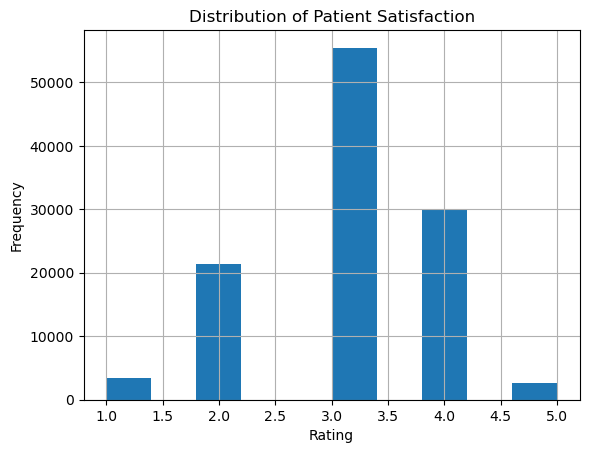


Model R² Score: -4.176571696357101e-05

Model Coefficient:
HCAHPS Answer Percent impact: 1.9750793991441835e-06


In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ================================
# 1. Load dataset
# ================================
df = pd.read_csv("cms_hospital_patient_satisfaction_2016.csv")

# ================================
# 2. Data Cleaning
# ================================

# Select relevant columns
df_clean = df[[ 
ko
    'Hospital overall rating',
    'HCAHPS Answer Percent',
    'HCAHPS Question',
    'Hospital Type',
    'Emergency Services'
]]

# Replace non-numeric values
df_clean = df_clean.replace(['Not Available', 'Not Applicable'], pd.NA)

# Convert numeric columns
df_clean['Hospital overall rating'] = pd.to_numeric(df_clean['Hospital overall rating'], errors='coerce')
df_clean['HCAHPS Answer Percent'] = pd.to_numeric(df_clean['HCAHPS Answer Percent'], errors='coerce')

# Drop missing values ONLY for key variables
df_clean = df_clean.dropna(subset=[
    'Hospital overall rating',
    'HCAHPS Answer Percent'
])

print("Cleaned shape:", df_clean.shape)

# ================================
# 3. Research Question 1:
# What factors influence satisfaction?
# ================================

# Correlation
correlation = df_clean[['Hospital overall rating', 'HCAHPS Answer Percent']].corr()
print("\nCorrelation Matrix:")
print(correlation)

# ================================
# 4. Research Question 2:
# Does hospital type affect satisfaction?
# ================================

print("\nSatisfaction by Hospital Type:")
print(df_clean.groupby('Hospital Type')['Hospital overall rating'].mean())

# ================================
# 5. Research Question 3:
# Does emergency service affect satisfaction?
# ================================

print("\nSatisfaction by Emergency Services:")
print(df_clean.groupby('Emergency Services')['Hospital overall rating'].mean())

# ================================
# 6. Research Question 4:
# Which aspects (questions) drive satisfaction?
# ================================

print("\nTop influencing questions:")
print(df_clean.groupby('HCAHPS Question')['Hospital overall rating'].mean().sort_values(ascending=False).head(10))

# ================================
# 7. Visualization
# ================================

# Distribution of satisfaction
df_clean['Hospital overall rating'].hist()
plt.title("Distribution of Patient Satisfaction")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# ================================
# 8. Predictive Model
# ================================

# Features and target
X = df_clean[['HCAHPS Answer Percent']]
y = df_clean['Hospital overall rating']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
print("\nModel R² Score:", model.score(X_test, y_test))

# ================================
# 9. Feature Importance
# ================================

print("\nModel Coefficient:")
print("HCAHPS Answer Percent impact:", model.coef_[0])